# Patterned Loading Sim
This is an implementation of the Patterned Loading feature. For the design specification please see the document Specification.md.

Ultimately, these tools will be used to reproduce the Patterned Loading experiments explained in the paper by S. Peil
1. Peil, S. & Porto, J. & Tolra, & Laburthe, B. & Obrecht, John & King, B. & Subbotin, M. & Rolston, Steven & Phillips, William. (2003). Patterned loading of a Bose-Einstein condensate into an optical lattice. Phys. Rev. A. 67. 051603. 10.1103/PhysRevA.67.051603. 

In [1]:
from oqtant.schemas.quantum_matter import QuantumMatterFactory
from oqtant.schemas.quantum_matter import QuantumMatter as qm
from oqtant.schemas.output import Gaussian_dist_2D
import numpy as np
import matplotlib.pyplot as plt

qmf = QuantumMatterFactory()
qmf.get_login()

Auth(children=(HBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x12\x00\x00\x00\xc…

In [2]:
qmf.get_client()

Job Limits:
╒═══════════════╤═══════════════════╤════════════════════╤════════════════════╕
│   Daily Limit │   Daily Remaining │   Standard Credits │   Priority Credits │
╞═══════════════╪═══════════════════╪════════════════════╪════════════════════╡
│            20 │                20 │                 46 │                  0 │
╘═══════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [3]:
from PatternedLoadingPkg.patterned_loader import PatternedLoader

In [4]:
recoilE = 3.8
shortPot = 12*recoilE
longPot = 5*recoilE
shortPot

45.599999999999994

### Experiment 1: Long no short (a)

In [5]:
pl = PatternedLoader(qmf)

s_pot = 0 #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 0. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 1. #ms
l_rise = 2.5 #ms also fall
l_hold = 0. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

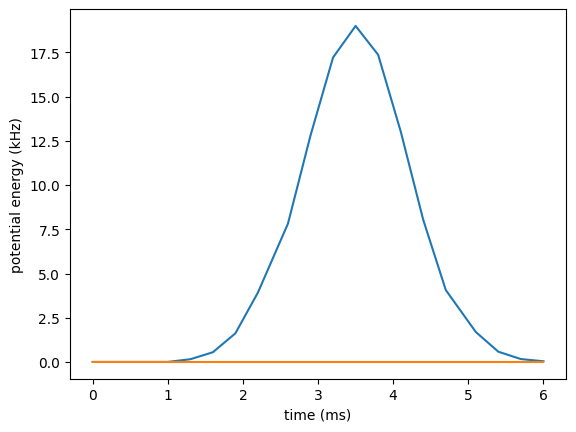

In [6]:
pl.show_superlattice_dynamics()

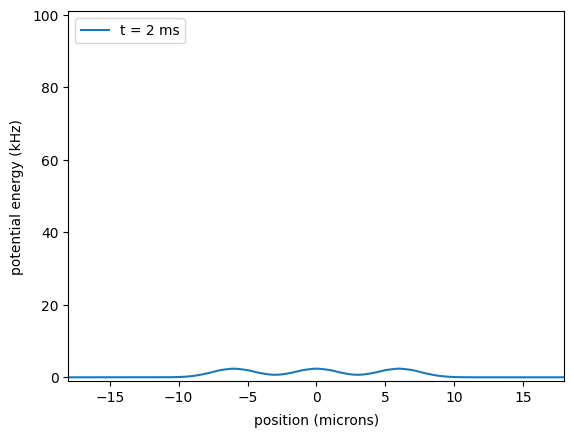

In [7]:
pl.get_matter("t").show_potential(times=[2], include_ideal=False, include_magnetic=False, xlimits=[-18,18])

In [8]:
repeats = 3
jobs = []
for rep in range(repeats):
    name = "Adiabatic_a_822" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [9]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: Adiabatic_a_822_rep_0
  Job ID: 1fc99697-8ebf-4cf6-85f9-73ead53666e5

Tracking 1 job(s):

- Job: Adiabatic_a_822_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_a_822_rep_1
  Job ID: 9c5926ba-7577-4c4b-9d1a-54a1b4f980c2

Tracking 1 job(s):

- Job: Adiabatic_a_822_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_a_822_rep_2
  Job ID: 23256410-205a-4dc6-97b8-badcf9e8ed47

Tracking 1 job(s):

- Job: Adiabatic_a_822_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete


[None, None, None]

In [10]:
superl = [matter.get_result() for matter in jobs]

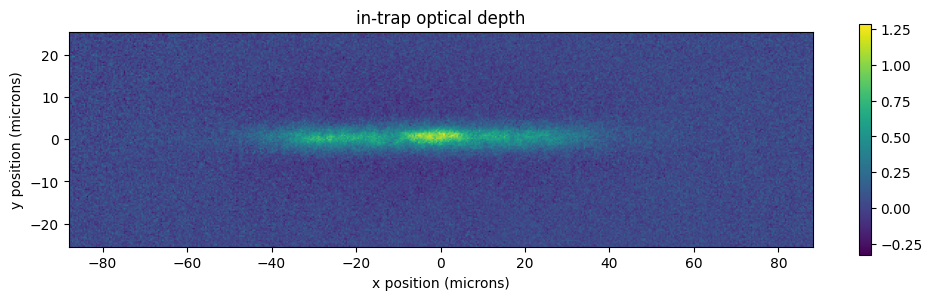

In [11]:
jobs[0].output.plot_it()

In [12]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_a_822_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_a_822_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_a_822_rep_2.txt"


### Experiment 2: (b)

In [13]:
pl = PatternedLoader(qmf, "b")

s_pot = shortPot #kHz
s_delay = 1. #ms
s_rise = 1. #ms also fall
s_hold = 3. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 1. #ms
l_rise = 2.5 #ms also fall
l_hold = 0. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

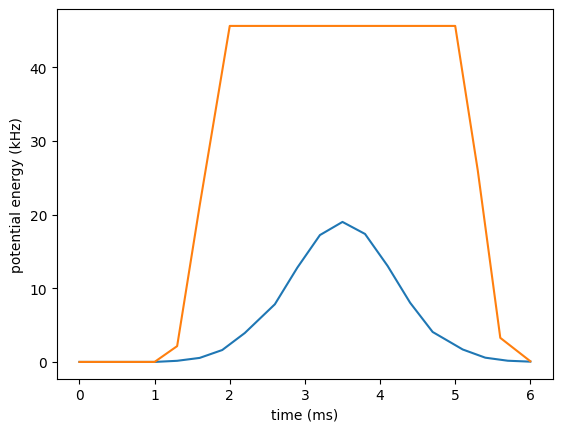

In [14]:
pl.show_superlattice_dynamics()

In [15]:
repeats = 3
jobs = []
for rep in range(repeats):
    name = "Adiabatic_b_822" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [16]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: Adiabatic_b_822_rep_0
  Job ID: 707dc9c0-1055-4b7a-a634-16372fb9417a

Tracking 1 job(s):

- Job: Adiabatic_b_822_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_b_822_rep_1
  Job ID: a518bdf2-dcfb-4157-8737-88e0ca68d959

Tracking 1 job(s):

- Job: Adiabatic_b_822_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_b_822_rep_2
  Job ID: 535319d7-fb76-4e04-b90e-5408b5f99080

Tracking 1 job(s):

- Job: Adiabatic_b_822_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete


[None, None, None]

In [17]:
[matter.get_result() for matter in jobs]

[None, None, None]

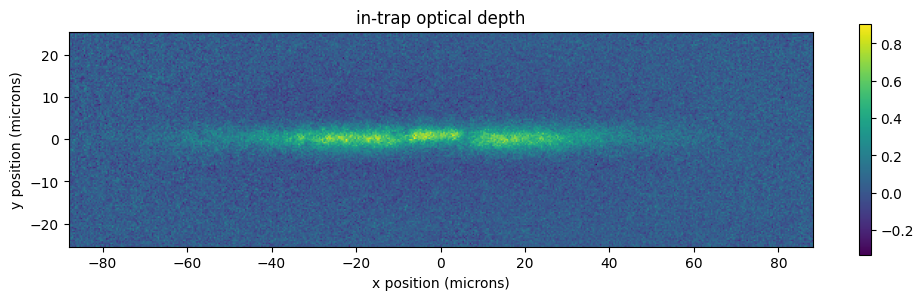

In [18]:
jobs[0].output.plot_it()

In [19]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_b_822_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_b_822_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_b_822_rep_2.txt"


### Experiment 3: (c)

In [20]:
pl = PatternedLoader(qmf, "c")

s_pot = shortPot #kHz
s_delay = 1. #ms
s_rise = 2.5 #ms also fall
s_hold = 0. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 1. #ms
l_rise = 1. #ms also fall
l_hold = 3. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

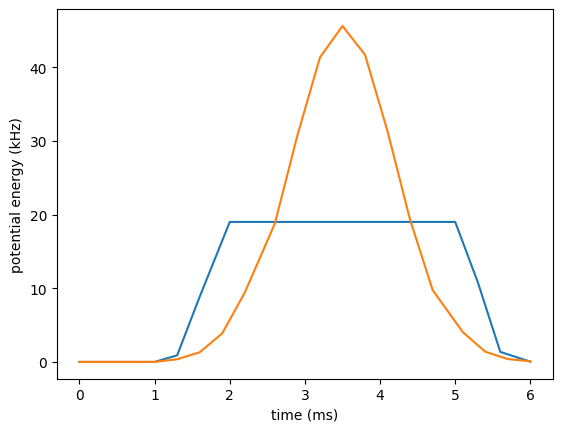

In [21]:
pl.show_superlattice_dynamics()

In [22]:
repeats = 3
jobs = []
for rep in range(repeats):
    name = "Adiabatic_c_822" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [23]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: Adiabatic_c_822_rep_0
  Job ID: 2d75cd15-972d-41ee-aa9f-eff169d0ee07

Tracking 1 job(s):

- Job: Adiabatic_c_822_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_c_822_rep_1
  Job ID: 5a5874e2-0d20-4090-8987-8563296698aa

Tracking 1 job(s):

- Job: Adiabatic_c_822_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_c_822_rep_2
  Job ID: b0a97beb-7dd6-4c3e-a4da-57ac93b30f6d

Tracking 1 job(s):

- Job: Adiabatic_c_822_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete


[None, None, None]

In [24]:
[matter.get_result() for matter in jobs]

[None, None, None]

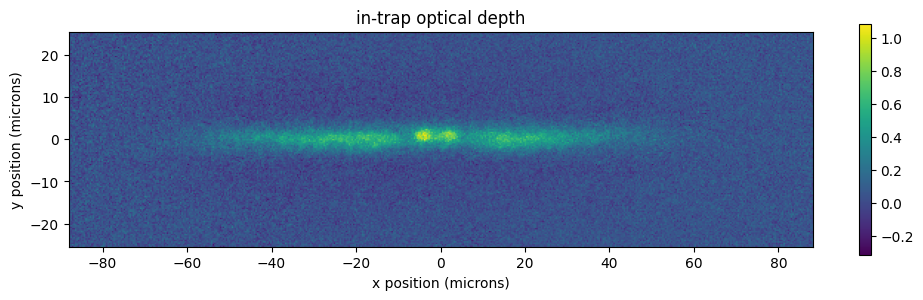

In [25]:
jobs[0].output.plot_it()

In [26]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_c_822_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_c_822_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_c_822_rep_2.txt"


### Experiment 4: (d)

In [27]:
pl = PatternedLoader(qmf, "d")

s_pot = shortPot #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 0. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 0. #ms
l_rise = 2.5 #ms also fall
l_hold = 0. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

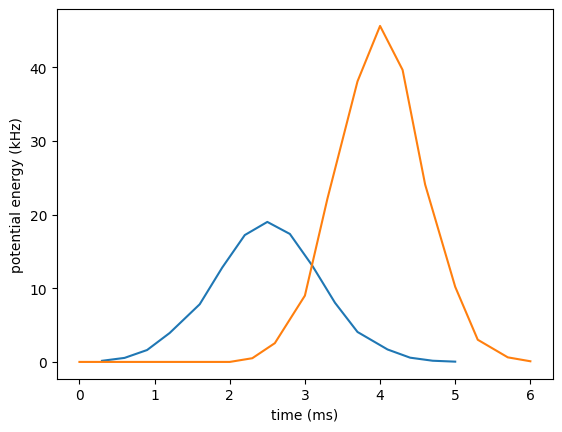

In [28]:
pl.show_superlattice_dynamics()

In [29]:
repeats = 3
jobs = []
for rep in range(repeats):
    name = "Adiabatic_d_822" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [30]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: Adiabatic_d_822_rep_0
  Job ID: 8a2586d0-fe6d-4cb0-889c-9de459c73803

Tracking 1 job(s):

- Job: Adiabatic_d_822_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_d_822_rep_1
  Job ID: 6fce6955-5627-4ba5-8108-e99635f3210c

Tracking 1 job(s):

- Job: Adiabatic_d_822_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: Adiabatic_d_822_rep_2
  Job ID: 0ee19018-32e9-491d-88f0-f76526578aff

Tracking 1 job(s):

- Job: Adiabatic_d_822_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete


[None, None, None]

In [31]:
[matter.get_result() for matter in jobs]

[None, None, None]

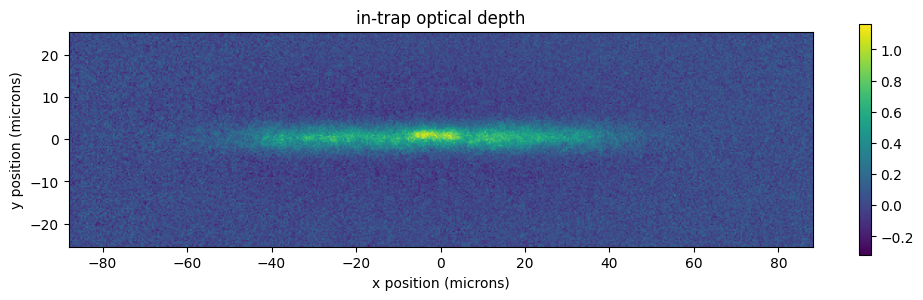

In [32]:
jobs[0].output.plot_it()

In [33]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_d_822_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_d_822_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\Adiabatic_d_822_rep_2.txt"
